# C1.2 — The Backward Euler Numerical Method

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.2.1 — Motivation

In the previous section, we studied the Forward Euler method:

$$
y_{n+1}=y_n+h f(t_n,y_n).
$$

Although simple and computationally efficient, Forward Euler can become unstable when:

- the step size is too large,
- the system evolves rapidly,
- the differential equation is stiff.

For many physical systems, especially dissipative systems, unstable numerical behavior is unacceptable. A stable physical system should not artificially explode due to poor numerical approximation.

To improve numerical stability, we introduce the **Backward Euler Method**.

The central idea is:

> Instead of using the slope at the current point, we use the slope at the future point.

This subtle modification dramatically improves stability properties.

Backward Euler is especially important for:

- stiff differential equations,
- diffusion equations,
- heat flow,
- circuit simulation,
- fluid dynamics,
- implicit time-stepping methods.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.2.2 — The Backward Euler Method

The Forward Euler method estimates the next value using the slope at the current point:

$$
y_{n+1}=y_n+h f(t_n,y_n).
$$

The **Backward Euler Method** instead uses the slope at the future point:

$$
y_{n+1}=y_n+h f(t_{n+1},y_{n+1}).
$$

This makes Backward Euler an **implicit method** because the unknown value $y_{n+1}$ appears on both sides of the equation.

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:12px; border-radius:4px;">
<strong>Backward Euler Method</strong>

For the differential equation

$$
\frac{dy}{dt}=f(t,y),
$$

the Backward Euler update is

$$
y_{n+1}=y_n+h f(t_{n+1},y_{n+1}).
$$

Unlike Forward Euler, this usually requires solving an algebraic equation at every time step.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.2.3 — Why the Method Is Called “Backward”

The name **Backward Euler** comes from approximating the derivative using a backward difference at the future point:

$$
\left.\frac{dy}{dt}\right|_{t_{n+1}}
\approx
\frac{y_{n+1}-y_n}{h}.
$$

Since

$$
\frac{dy}{dt}=f(t,y),
$$

we evaluate the right-hand side at the future point:

$$
\frac{y_{n+1}-y_n}{h}=f(t_{n+1},y_{n+1}).
$$

Solving for $y_{n+1}$ gives

$$
y_{n+1}=y_n+h f(t_{n+1},y_{n+1}).
$$

The method looks backward because the derivative at $t_{n+1}$ is approximated using the interval from $t_n$ to $t_{n+1}$.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.2.4 — Explicit Versus Implicit Methods

Forward Euler is an **explicit method** because the next value is computed directly:

$$
y_{n+1}=y_n+h f(t_n,y_n).
$$

Backward Euler is an **implicit method** because the next value is defined by an equation:

$$
y_{n+1}=y_n+h f(t_{n+1},y_{n+1}).
$$

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:12px; border-radius:4px;">
<strong>Explicit Method</strong>

A method is explicit if the next value $y_{n+1}$ can be computed directly from known information.

<br><br>

<strong>Implicit Method</strong>

A method is implicit if the next value $y_{n+1}$ must be found by solving an equation involving $y_{n+1}$ itself.
</div>

Implicit methods are usually more computationally expensive, but they often have much better stability properties.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.2.5 — Algorithmic Procedure

The Backward Euler algorithm follows these steps:

1. Define the differential equation:

   $$
   \frac{dy}{dt}=f(t,y).
   $$

2. Choose:

   - initial condition $(t_0,y_0)$,
   - step size $h$,
   - number of steps.

3. At each step, solve the implicit equation:

   $$
   y_{n+1}=y_n+h f(t_{n+1},y_{n+1}).
   $$

4. Advance time:

   $$
   t_{n+1}=t_n+h.
   $$

5. Repeat until the desired final time is reached.

<div style="background-color:#ffe6e6; border-left:6px solid #cc0000; padding:14px; border-radius:4px;">
<strong>Danger:</strong><br>

Backward Euler is not usually a plug-in formula. In many problems, each step requires solving an algebraic equation. For nonlinear differential equations, this may require numerical root-finding.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.2.6 — Example: Exponential Decay

<div style="background-color:#e0f7fa; border-left:6px solid #006a80; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Example — Backward Euler for Exponential Decay</h3>
Consider the differential equation

$$
\frac{dy}{dt}=-ky,
$$

where $k>0$.

This describes exponential decay, such as radioactive decay, cooling, or a simple dissipative system.

Using Backward Euler,

$$
y_{n+1}=y_n+h(-k y_{n+1}).
$$

Now solve for $y_{n+1}$:

$$
y_{n+1}=y_n-hk y_{n+1}.
$$

Move all $y_{n+1}$ terms to one side:

$$
y_{n+1}+hk y_{n+1}=y_n.
$$

Factor:

$$
(1+hk)y_{n+1}=y_n.
$$

Therefore,

$$
y_{n+1}=\frac{y_n}{1+hk}.
$$

For

$$
\frac{dy}{dt}=-ky,
$$

Backward Euler gives

$$
y_{n+1}=\frac{y_n}{1+hk}.
$$

Since $1+hk>1$, each step reduces the magnitude of $y_n$. This means the numerical solution decays rather than artificially growing.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.2.7 — Stability Comparison with Forward Euler

For the same equation,

$$
\frac{dy}{dt}=-ky,
$$

Forward Euler gives

$$
y_{n+1}=y_n-hk y_n.
$$

Therefore,

$$
y_{n+1}=(1-hk)y_n.
$$

Backward Euler gives

$$
y_{n+1}=\frac{1}{1+hk}y_n.
$$

The difference is important.

For Forward Euler, the multiplier is

$$
1-hk.
$$

If $h$ is too large, this factor can become negative or have magnitude larger than one, causing oscillation or growth.

For Backward Euler, the multiplier is

$$
\frac{1}{1+hk}.
$$

For $h>0$ and $k>0$, this factor always has magnitude less than one.

<div style="background-color:#fff8e1; border-left:6px solid #ffcc00; padding:14px; border-radius:4px;">
<strong>Numerical Insight</strong>

Backward Euler is especially useful for systems that physically decay. Even with large time steps, the method tends to preserve the qualitative behavior of decay.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.2.8 — Physical Interpretation

The Forward Euler method asks:

> What happens if the current slope continues forward for one step?

The Backward Euler method asks:

> What value at the next time makes the future slope consistent with the step we just took?

This makes Backward Euler more cautious. It uses information from the endpoint of the interval rather than the beginning.

For rapidly changing or dissipative systems, this future-point evaluation often prevents runaway numerical behavior.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.2.9 — Box Activity: Compare Forward and Backward Euler

<div style="background-color:#e8f5e9; border-left:6px solid #006633; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Box Activity — Exponential Decay with a Large Step Size</h3>

Consider the differential equation

$$
\frac{dy}{dt}=-5y,
$$

with initial condition

$$
y(0)=1.
$$

Use a step size

$$
h=0.5.
$$

Answer the following:

1. Find the Forward Euler update formula.
2. Find the Backward Euler update formula.
3. Compute $y_1$ using both methods.
4. Which method better preserves the expected physical behavior?

<details>
<summary style="background-color:#006633; color:white; padding:8px; border-radius:4px; cursor:pointer;">
Activity solution
</summary>

For Forward Euler,

$$
y_{n+1}=y_n+h(-5y_n).
$$

So

$$
y_{n+1}=(1-5h)y_n.
$$

With $h=0.5$,

$$
y_{n+1}=(1-2.5)y_n=-1.5y_n.
$$

Since $y_0=1$,

$$
y_1=-1.5.
$$

This is unphysical for a simple positive decay problem.

For Backward Euler,

$$
y_{n+1}=y_n+h(-5y_{n+1}).
$$

So

$$
y_{n+1}+5h y_{n+1}=y_n.
$$

Therefore,

$$
y_{n+1}=\frac{y_n}{1+5h}.
$$

With $h=0.5$,

$$
y_1=\frac{1}{1+2.5}.
$$

Thus,

$$
y_1=\frac{1}{3.5}\approx 0.286.
$$

Backward Euler preserves the expected behavior: the solution remains positive and decays.

</details>
</div>

---

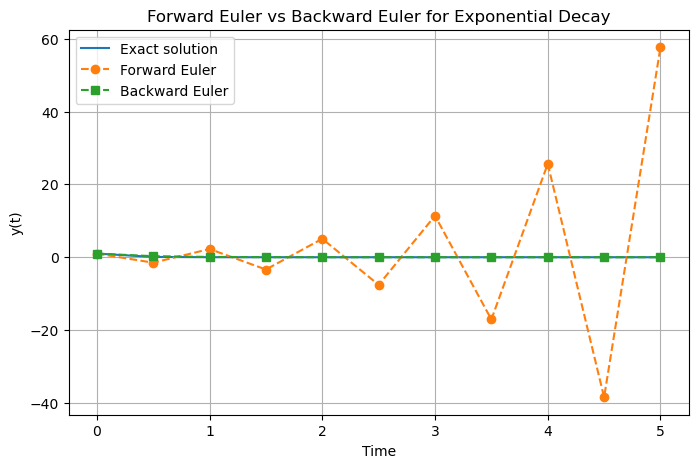

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k = 5.0
h = 0.5
t_final = 5.0

# Time array
t = np.arange(0, t_final + h, h)

# Arrays
y_forward = np.zeros_like(t)
y_backward = np.zeros_like(t)
y_exact = np.exp(-k*t)

# Initial condition
y_forward[0] = 1.0
y_backward[0] = 1.0

# Euler updates
for n in range(len(t)-1):
    y_forward[n+1] = y_forward[n] + h*(-k*y_forward[n])
    y_backward[n+1] = y_backward[n] / (1 + h*k)

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, y_exact, label="Exact solution")
plt.plot(t, y_forward, "o--", label="Forward Euler")
plt.plot(t, y_backward, "s--", label="Backward Euler")
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("Forward Euler vs Backward Euler for Exponential Decay")
plt.grid(True)
plt.legend()
plt.show()

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.2.10 — Nonlinear Problems

For simple linear equations, Backward Euler may be solved algebraically.

However, for nonlinear equations, the implicit equation may be more difficult.

For example, consider

$$
\frac{dy}{dt}=y^2-t.
$$

Backward Euler gives

$$
y_{n+1}=y_n+h(y_{n+1}^2-t_{n+1}).
$$

This is not a direct formula for $y_{n+1}$. Instead, we must solve

$$
y_{n+1}-y_n-h(y_{n+1}^2-t_{n+1})=0.
$$

This is a root-finding problem.

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:12px; border-radius:4px;">
<strong>Implicit Equation Form</strong>

Backward Euler often leads to an equation of the form

$$
G(y_{n+1})=0.
$$

The goal at each step is to find the value of $y_{n+1}$ that makes this equation true.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.2.11 — Solving the Implicit Equation Numerically

A common way to solve the implicit equation is to define

$$
G(y_{n+1})=y_{n+1}-y_n-h f(t_{n+1},y_{n+1}).
$$

Then we solve

$$
G(y_{n+1})=0.
$$

This can be done using numerical methods such as:

- fixed-point iteration,
- Newton's method,
- bisection,
- built-in root solvers.

For many physics applications, Newton's method is especially common.

<div style="background-color:#ffe6e6; border-left:6px solid #cc0000; padding:14px; border-radius:4px;">
<strong>Danger:</strong><br>

Backward Euler improves stability, but it does not remove all numerical challenges. If the implicit equation is solved poorly, the method can still give inaccurate results.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.2.12 — Summary

The Backward Euler Method is given by

$$
y_{n+1}=y_n+h f(t_{n+1},y_{n+1}).
$$

Its key features are:

- it uses the slope at the future point,
- it is an implicit method,
- it usually requires solving an equation at each step,
- it is more stable than Forward Euler for many dissipative systems,
- it is especially useful for stiff differential equations.

The main tradeoff is:

$$
\text{better stability} \quad \longleftrightarrow \quad \text{more computational work}.
$$

Backward Euler is one of the simplest examples of an implicit numerical method, making it an important bridge between basic numerical methods and more advanced time-stepping algorithms.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">